In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path

In [3]:
path = {
'coords': '/home/vicentev/projects/def-allen/vicentev/analysis-vicente/grid/coordinates_seagrid_SalishSea201702.nc',
'mask': '/home/vicentev/projects/def-allen/vicentev/analysis-vicente/grid/mesh_mask202108_TDV.nc',
'bathy':'/home/vicentev/projects/def-allen/vicentev/analysis-vicente/grid/bathymetry_202108.nc'
}
#
coords = xr.open_dataset(path['coords'], decode_times=False)
mask = xr.open_dataset(path['mask'])
bathy = xr.open_dataset(path['bathy'])

In [4]:
def finder2(target_lat, target_lon,mask=mask):
    lat = mask.nav_lat
    lon = mask.nav_lon
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [5]:
Nx1_1, Ny1_1 = [132,170], [665,680]
Nx1_2, Ny1_2 = [170,200], [680,620]
Nx1_3, Ny1_3 = [135,200], [620,620]
#
polygon_coords_N1 = [
    (Nx1_1[0], Ny1_1[0]),
    (Nx1_1[1], Ny1_1[1]),
    (Nx1_2[1], Ny1_2[1]),
    (Nx1_3[1], Ny1_3[1]),
    (Nx1_3[0], Ny1_3[0])
]
polygon_N1 = Polygon(polygon_coords_N1)
#
N1_lon_1, N1_lat_1 = [mask.nav_lon[Ny1_1[0],Nx1_1[0]].values, mask.nav_lon[Ny1_1[1],Nx1_1[1]].values], [mask.nav_lat[Ny1_1[0],Nx1_1[0]].values, mask.nav_lat[Ny1_1[1],Nx1_1[1]].values]
N1_lon_2, N1_lat_2 = [mask.nav_lon[Ny1_2[0],Nx1_2[0]].values, mask.nav_lon[Ny1_2[1],Nx1_2[1]].values], [mask.nav_lat[Ny1_2[0],Nx1_2[0]].values, mask.nav_lat[Ny1_2[1],Nx1_2[1]].values]
N1_lon_3, N1_lat_3 = [mask.nav_lon[Ny1_3[0],Nx1_3[0]].values, mask.nav_lon[Ny1_3[1],Nx1_3[1]].values], [mask.nav_lat[Ny1_3[0],Nx1_3[0]].values, mask.nav_lat[Ny1_3[1],Nx1_3[1]].values]
#
polygon_lon_lat_N1 = [
    (N1_lon_1[0], N1_lat_1[0]),
    (N1_lon_1[1], N1_lat_1[1]),
    (N1_lon_2[1], N1_lat_2[1]),
    (N1_lon_3[1], N1_lat_3[1]),
    (N1_lon_3[0], N1_lat_3[0])
]
polygon_coors_N1 = Polygon(polygon_lon_lat_N1)


In [6]:
Sx1_1, Sy1_1 = [202,292], [505,505]
Sx1_2, Sy1_2 = [300,315], [505,480]
Sx1_3, Sy1_3 = [210,238], [500,465]
Sx1_4, Sy1_4 = [238,245], [465,410]
Sx1_5, Sy1_5 = [302, 280], [410, 470]
Sx1_6, Sy1_6 = [245,302], [410,410]
#
polygon_coords_S1 = [
    (Sx1_1[0], Sy1_1[0]),
    (Sx1_1[1], Sy1_1[1]),
    (Sx1_5[1], Sy1_5[1]),
    (Sx1_4[0], Sy1_4[0])
]
polygon_S1 = Polygon(polygon_coords_S1)
#
S1_lon_1, S1_lat_1 = [mask.nav_lon[Sy1_1[0],Sx1_1[0]].values, mask.nav_lon[Sy1_1[1],Sx1_1[1]].values], [mask.nav_lat[Sy1_1[0],Sx1_1[0]].values, mask.nav_lat[Sy1_1[1],Sx1_1[1]].values]
S1_lon_2, S1_lat_2 = [mask.nav_lon[Sy1_2[0],Sx1_2[0]].values, mask.nav_lon[Sy1_2[1],Sx1_2[1]].values], [mask.nav_lat[Sy1_2[0],Sx1_2[0]].values, mask.nav_lat[Sy1_2[1],Sx1_2[1]].values]
S1_lon_3, S1_lat_3 = [mask.nav_lon[Sy1_3[0],Sx1_3[0]].values, mask.nav_lon[Sy1_3[1],Sx1_3[1]].values], [mask.nav_lat[Sy1_3[0],Sx1_3[0]].values, mask.nav_lat[Sy1_3[1],Sx1_3[1]].values]
S1_lon_4, S1_lat_4 = [mask.nav_lon[Sy1_4[0],Sx1_4[0]].values, mask.nav_lon[Sy1_4[1],Sx1_4[1]].values], [mask.nav_lat[Sy1_4[0],Sx1_4[0]].values, mask.nav_lat[Sy1_4[1],Sx1_4[1]].values]
S1_lon_5, S1_lat_5 = [mask.nav_lon[Sy1_5[0],Sx1_5[0]].values, mask.nav_lon[Sy1_5[1],Sx1_5[1]].values], [mask.nav_lat[Sy1_5[0],Sx1_5[0]].values, mask.nav_lat[Sy1_5[1],Sx1_5[1]].values]
S1_lon_6, S1_lat_6 = [mask.nav_lon[Sy1_6[0],Sx1_6[0]].values, mask.nav_lon[Sy1_6[1],Sx1_6[1]].values], [mask.nav_lat[Sy1_6[0],Sx1_6[0]].values, mask.nav_lat[Sy1_6[1],Sx1_6[1]].values]
#
polygon_lon_lat_S1 = [
    (S1_lon_1[0], S1_lat_1[0]),
    (S1_lon_1[1], S1_lat_1[1]),
    (S1_lon_5[1], S1_lat_5[1]),
    (S1_lon_4[0], S1_lat_4[0])
]
polygon_coors_S1 = Polygon(polygon_lon_lat_S1)

In [7]:
NG = [49.727, -124.68]
S415 = [49.25, -123.667]
y_N1, x_N1 = finder2(NG[0], NG[1])
y_S1, x_S1 = finder2(S415[0], S415[1])

In [8]:
lat_source = 49.195045
lon_source = -123.301956
y_source, x_source = finder2(lat_source, lon_source)

In [9]:
def volume_region_50m_bottom(polygon):
    mesh = xr.open_dataset(path['mask'])
    volume = mesh['volume']
    mask = xr.open_dataset(path['mask'])['tmask'][0]
    #
    depths = mesh['gdept_1d'][0] 
    depth_condition = depths >= 50
    # 
    depth_mask_3d = depth_condition.values[:, np.newaxis, np.newaxis]
    #    
    x = volume['x']  
    y = volume['y'] 
    #
    xx, yy = np.meshgrid(x, y)
    #
    # 2D Polygon Mask
    polygon_mask_2d = np.array([
        [polygon.contains(Point(xx[j, i], yy[j, i])) for i in range(len(x))]
        for j in range(len(y))
    ])

    # to 3D
    nz = volume.sizes['z']
    polygon_mask_3d = np.repeat(polygon_mask_2d[np.newaxis, :, :], nz, axis=0)

    # inside polygon  + in water + > 50 m
    combined_mask = (polygon_mask_3d & (mask.values == 1) & depth_mask_3d)

    # Applying mask
    mask_da = xr.DataArray(combined_mask, dims=volume.dims, coords=volume.coords)
    volume_in_polygon_water = volume.where(mask_da).sum().item()
    
    return volume_in_polygon_water

In [10]:
volume_N1 = volume_region_50m_bottom(polygon_N1)
volume_S1 = volume_region_50m_bottom(polygon_S1)
print(volume_N1/1e9, 'km^3')
print(volume_S1/1e9, 'km^3')

64.30395579 km^3
109.140915985 km^3


In [11]:
def polygon_definition_data_colloidal(ds, region_polygon,  depth_min=50):
#
    lons = ds['lon'].values
    lats = ds['lat'].values
    depths = ds['z'].values
    statuses = ds['status'].values
    #
    points_flat = np.column_stack((lons.ravel(), lats.ravel()))
    poly_path = Path(region_polygon)
    # points inside polygon
    inside_mask_flat = poly_path.contains_points(points_flat)
    inside_mask = inside_mask_flat.reshape(lons.shape)
    # >= 50 mask
    deep_mask = depths >= depth_min
    #deep_mask = depths >= depth_min
    # Colloidal status 
    status_mask = np.isin(statuses, 2) 
    #
    valid_mask = inside_mask & deep_mask & status_mask
    #
    counts = np.sum(valid_mask, axis=0) 
    #
    times = ds['time'].values
    time_index = np.nanmax(times, axis=0) 
    #
    return pd.DataFrame({'count': counts}, index=time_index)

In [12]:
def particles_amount(
    lons, lats, mask=mask, num_lon=200, num_lat=200
):
    nav_lon = mask['nav_lon'].values
    nav_lat = mask['nav_lat'].values

    lon_edges = np.linspace(nav_lon.min(), nav_lon.max(), num_lon + 1)
    lat_edges = np.linspace(nav_lat.min(), nav_lat.max(), num_lat + 1)

    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2

    counts, xedges, yedges = np.histogram2d(
        lons, lats,
        bins=[lon_edges, lat_edges]
    )

    df = pd.DataFrame(
        counts.T,  
        index=lat_centers,
        columns=lon_centers
    )

    Xcenters, Ycenters = np.meshgrid(lon_centers, lat_centers)

    flat_lon = Xcenters.ravel()
    flat_lat = Ycenters.ravel()

    ii_sed = np.zeros(flat_lon.size, dtype=int)
    jj_sed = np.zeros(flat_lon.size, dtype=int)

    for k in range(flat_lon.size):
        jj, ii = finder2(flat_lat[k], flat_lon[k], mask)
        ii_sed[k] = ii
        jj_sed[k] = jj

    ii_sed = ii_sed.reshape(Xcenters.shape)
    jj_sed = jj_sed.reshape(Ycenters.shape)

    grid_indices = (ii_sed, jj_sed)

    raw_hist = (counts, xedges, yedges)

    return df, raw_hist, grid_indices


In [13]:
def proportions(data):
    colloidal_water = []
    marine_water = [] 
    sewage_water = []
    initial = []
    colloidal_sediment = []
    marine_sediment = []
    sewage_sediment = []
    particles_out_jdf = []
    particles_out_js = []
    total = []

    for i in range(len(data.obs)):
        status_i = data.status[:, i].values
        lat_i = data.lat[:, i].values
        lon_i = data.lon[:, i].values

        # Mask to keep only rows without NaNs
        valid_mask = (
            np.isfinite(status_i) &
            np.isfinite(lat_i) &
            np.isfinite(lon_i)
        )
        status_i = status_i[valid_mask]
        lat_i = lat_i[valid_mask]
        lon_i = lon_i[valid_mask]

        # Total valid particles
        len_T = len(status_i)

        if len_T == 0:
            # Append NaNs if no data for this time step
            initial.append(np.nan)
            colloidal_water.append(np.nan)
            marine_water.append(np.nan)
            sewage_water.append(np.nan)
            colloidal_sediment.append(np.nan)
            marine_sediment.append(np.nan)
            sewage_sediment.append(np.nan)
            particles_out_jdf.append(np.nan)
            particles_out_js.append(np.nan)
            total.append(0)
            continue

        # Counts by status
        len_initial = np.count_nonzero(status_i < 0)
        len_1 = np.count_nonzero(status_i == 1)
        len_2 = np.count_nonzero(status_i == 2)
        len_3 = np.count_nonzero(status_i == 3)
        len_11 = np.count_nonzero(status_i == 11)
        len_12 = np.count_nonzero(status_i == 12)
        len_13 = np.count_nonzero(status_i == 13)

        # Location counts
        len_jdf = np.count_nonzero((lat_i < 48.7) & (lon_i < -124.66))
        len_js = np.count_nonzero(lon_i < -126)

        # Append results
        initial.append(len_initial)
        colloidal_water.append(len_2)
        marine_water.append(len_3) 
        sewage_water.append(len_1)
        colloidal_sediment.append(len_12)
        marine_sediment.append(len_13)
        sewage_sediment.append(len_11)
        particles_out_jdf.append(len_jdf)
        particles_out_js.append(len_js)    
        total.append(len_T)

    total_arr = np.array(total, dtype=float)

    # Avoid divide-by-zero: will give NaN where total_arr == 0
    proportion_initial = np.array(initial, dtype=float)# / total_arr
    p_colloidal_water = np.array(colloidal_water, dtype=float)# / total_arr
    p_marine_water = np.array(marine_water, dtype=float)# / total_arr
    p_sewage_water = np.array(sewage_water, dtype=float)# / total_arr
    p_colloidal_sediment = np.array(colloidal_sediment, dtype=float)# / total_arr
    p_marine_sediment = np.array(marine_sediment, dtype=float)# / total_arr
    p_sewage_sediment = np.array(sewage_sediment, dtype=float)# / total_arr
    p_out_jdf = np.array(particles_out_jdf, dtype=float)# / total_arr
    p_out_js = np.array(particles_out_js, dtype=float)# / total_arr

    data_array = np.column_stack([
        proportion_initial,# * 100,
        p_colloidal_water,# * 100,
        p_marine_water,# * 100,
        p_sewage_water,# * 100,
        p_colloidal_sediment,# * 100,
        p_marine_sediment,# * 100,
        p_sewage_sediment,# * 100,
        p_out_jdf,# * 100,
        p_out_js,# * 100,
        total_arr
    ])

    data_proportions = pd.DataFrame(
        data=data_array,
        columns=[
            'initial',
            'colloidal_water',
            'marine_water',
            'sewage_water',
            'colloidal_sediment',
            'marine_sediment',
            'sewage_sediment',
            'out_jdf',
            'out_js',
            'total_len'
        ]
    )

    return data_proportions


# Best Versions

In [14]:
files = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_005_Ads_0_1_Vel_Hx1_2.nc', 
         '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_ADS_0_01_TAU_0_005_MC_0_2.nc', 
         '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_005_Ads_0_05_Vel_Hx1_2.nc']

In [15]:
data_V1, data_V2, data_V3 = xr.open_dataset(files[0]), xr.open_dataset(files[1]), xr.open_dataset(files[2])

In [16]:
#prop_V1, prop_V2, prop_V3 = proportions(data_V1.isel(obs=slice(0,1215))), proportions(data_V2.isel(obs=slice(0,1215))), proportions(data_V3.isel(obs=slice(0,1215)))

In [17]:
counts_S1_V1 = polygon_definition_data_colloidal(data_V1.isel(obs=slice(1092,1215)), polygon_lon_lat_S1)
counts_N1_V1 = polygon_definition_data_colloidal(data_V1.isel(obs=slice(1092,1215)), polygon_lon_lat_N1)
concentration_S1_V1 = np.sum(counts_S1_V1) / volume_S1 / len(data_V1.isel(obs=slice(1092,1215))['obs'])
concentration_N1_V1 = np.sum(counts_N1_V1) / volume_N1 / len(data_V1.isel(obs=slice(1092,1215))['obs'])
ratio_S1_N1_V1 = concentration_S1_V1 / concentration_N1_V1
#
counts_S1_V2 = polygon_definition_data_colloidal(data_V2.isel(obs=slice(1092,1215)), polygon_lon_lat_S1)
counts_N1_V2 = polygon_definition_data_colloidal(data_V2.isel(obs=slice(1092,1215)), polygon_lon_lat_N1)
concentration_S1_V2 = np.sum(counts_S1_V2) / volume_S1 / len(data_V2.isel(obs=slice(1092,1215))['obs'])
concentration_N1_V2 = np.sum(counts_N1_V2) / volume_N1 / len(data_V2.isel(obs=slice(1092,1215))['obs'])
ratio_S1_N1_V2 = concentration_S1_V2 / concentration_N1_V2
#

counts_S1_V3 = polygon_definition_data_colloidal(data_V3.isel(obs=slice(1092,1215)), polygon_lon_lat_S1)
counts_N1_V3 = polygon_definition_data_colloidal(data_V3.isel(obs=slice(1092,1215)), polygon_lon_lat_N1)
concentration_S1_V3 = np.sum(counts_S1_V3) / volume_S1 / len(data_V3.isel(obs=slice(1092,1215))['obs'])
concentration_N1_V3 = np.sum(counts_N1_V3) / volume_N1 / len(data_V3.isel(obs=slice(1092,1215))['obs'])
ratio_S1_N1_V3 = concentration_S1_V3 / concentration_N1_V3

/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or 

In [18]:
wc_V1 = data_V1.isel(obs=slice(1092,1215)).where(data_V1.isel(obs=slice(1092,1215))['status'] == 2)
wc_V2 = data_V2.isel(obs=slice(1092,1215)).where(data_V2.isel(obs=slice(1092,1215))['status'] == 2)
wc_V3 = data_V3.isel(obs=slice(1092,1215)).where(data_V3.isel(obs=slice(1092,1215))['status'] == 2)
#
amount_V1, _, grid_ijV1 = particles_amount(wc_V1['lon'].values.flatten(), wc_V1['lat'].values.flatten())
amount_V2, _, grid_ijV2 = particles_amount(wc_V2['lon'].values.flatten(), wc_V2['lat'].values.flatten())
amount_V3, _, grid_ijV3 = particles_amount(wc_V3['lon'].values.flatten(), wc_V3['lat'].values.flatten())

In [19]:
plt.rcParams.update({'font.size': 16})
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)

/tmp/ipykernel_2956094/3163398247.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  V1_plot = ax[0].pcolormesh(grid_ijV1[0], grid_ijV1[1], amount_V1,
/tmp/ipykernel_2956094/3163398247.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  V2_plot = ax[1].pcolormesh(grid_ijV2[0], grid_ijV2[1], amount_V2,
/tmp/ipykernel_2956094/3163398247.py:40: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcol

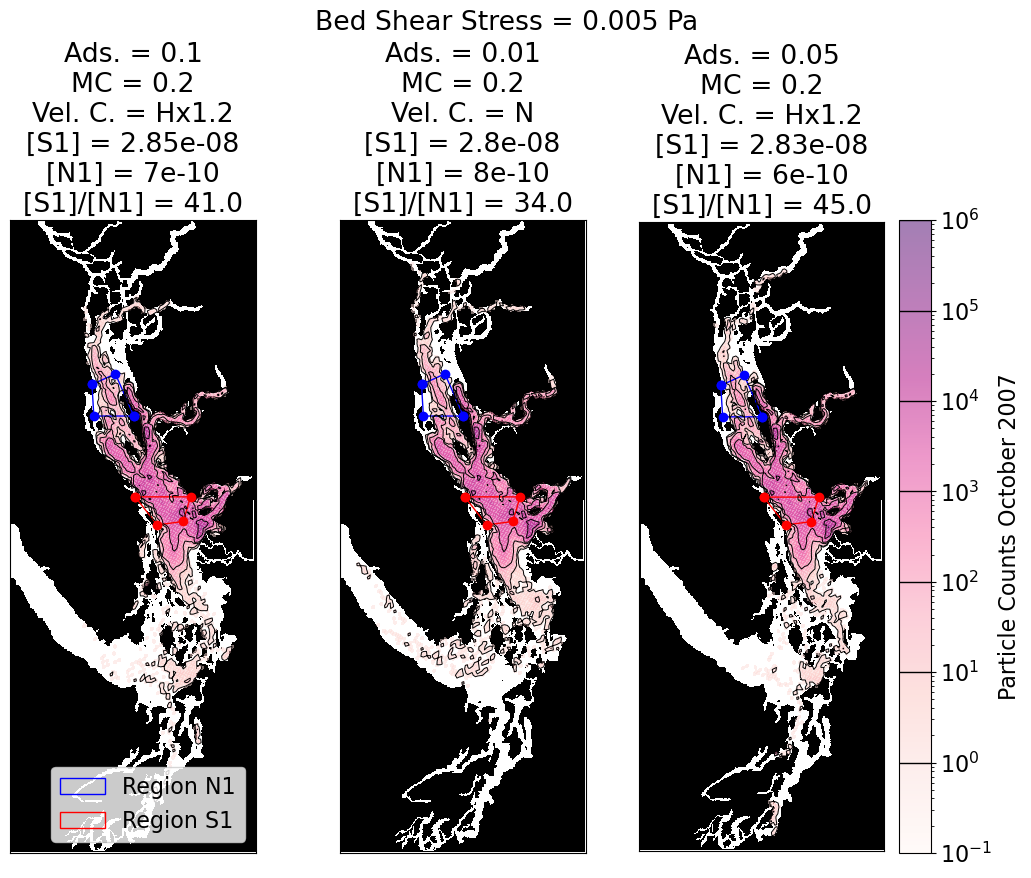

In [20]:
levels = [1, 10e0, 10e1, 10e2, 10e3, 10e4, 10e5]
#
fig, ax = plt.subplots(1,3, figsize = (11,9))
ax[0].pcolormesh(mask['tmask'][0][0], cmap = cmap)
#ax[0].contour(bathy['Bathymetry'], cmap = 'Greys')
V1_plot = ax[0].pcolormesh(grid_ijV1[0], grid_ijV1[1], amount_V1,
                 norm=colors.LogNorm(vmin=amount_V1.min().min() + 1e-1, vmax=10e5), 
                 cmap = 'RdPu', alpha = .5)
#
ax[0].contour(grid_ijV1[0], grid_ijV1[1], amount_V1, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
#
plot_polygon(polygon_N1, ax=ax[0], color = 'b', label = 'Region N1', fill=False)
plot_polygon(polygon_S1, ax=ax[0], color = 'r', label = 'Region S1', fill=False)
#
ax[0].set_title('Ads. = 0.1' + '\n' + 'MC = 0.2' + '\n' + 'Vel. C. = Hx1.2' + '\n' +
                rf'[S1] = {np.round(concentration_S1_V1.values[0],10)}' + '\n' 
                + rf'[N1] = {np.round(concentration_N1_V1.values[0], 10)}' + '\n' 
                + rf'[S1]/[N1] = {np.round(ratio_S1_N1_V1.values[0])}' )
#
ax[1].pcolormesh(mask['tmask'][0][0], cmap = cmap)
#ax[1].contour(bathy['Bathymetry'], cmap = 'Greys')
V2_plot = ax[1].pcolormesh(grid_ijV2[0], grid_ijV2[1], amount_V2,
                 norm=colors.LogNorm(vmin=amount_V2.min().min() + 1e-1, vmax=10e5), 
                 cmap = 'RdPu', alpha = .5)
#
ax[1].contour(grid_ijV2[0], grid_ijV2[1], amount_V2, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
#
plot_polygon(polygon_N1, ax=ax[1], color = 'b', label = 'Region N1', fill=False)
plot_polygon(polygon_S1, ax=ax[1], color = 'r', label = 'Region S1', fill=False)
#
ax[1].set_title('Ads. = 0.01' + '\n' + 'MC = 0.2' + '\n' + 'Vel. C. = N' + '\n' +
                rf'[S1] = {np.round(concentration_S1_V2.values[0],10)}' + '\n' 
                + rf'[N1] = {np.round(concentration_N1_V2.values[0], 10)}' + '\n' 
                + rf'[S1]/[N1] = {np.round(ratio_S1_N1_V2.values[0])}' )
#
ax[2].pcolormesh(mask['tmask'][0][0], cmap = cmap)
#ax[1].contour(bathy['Bathymetry'], cmap = 'Greys')
V3_plot = ax[2].pcolormesh(grid_ijV3[0], grid_ijV3[1], amount_V3,
                 norm=colors.LogNorm(vmin=amount_V3.min().min() + 1e-1, vmax=10e5), 
                 cmap = 'RdPu', alpha = .5)
#
ax[2].contour(grid_ijV3[0], grid_ijV3[1], amount_V3, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
#
plot_polygon(polygon_N1, ax=ax[2], color = 'b', label = 'Region N1', fill=False)
plot_polygon(polygon_S1, ax=ax[2], color = 'r', label = 'Region S1', fill=False)
#
ax[2].set_title('Ads. = 0.05' + '\n' + 'MC = 0.2' + '\n' + 'Vel. C. = Hx1.2' + '\n' +
                rf'[S1] = {np.round(concentration_S1_V3.values[0],10)}' + '\n' 
                + rf'[N1] = {np.round(concentration_N1_V3.values[0], 10)}' + '\n' 
                + rf'[S1]/[N1] = {np.round(ratio_S1_N1_V3.values[0])}' )
#


#cbar_t1 = plt.colorbar(t1_plot, ax = ax[0])
cbar_V3 = plt.colorbar(V3_plot, ax = ax[2])
cbar_V3.set_label('Particle Counts October 2007')
for lev in levels:
    cbar_V3.ax.hlines(
        lev, 
        *cbar_V3.ax.get_xlim(),   # span full width
        colors='black',
        linewidth=1
    )
#
for axis in ax:
    axis.set_aspect(1.14)
    axis.set_xticks([])
    axis.set_yticks([])
ax[0].legend(loc = 'lower right')    
#
plt.suptitle('Bed Shear Stress = 0.005 Pa')
plt.tight_layout()

In [21]:
counts_S1_V1_total = polygon_definition_data_colloidal(data_V1.isel(obs=slice(0,1215)), polygon_lon_lat_S1)
counts_N1_V1_total = polygon_definition_data_colloidal(data_V1.isel(obs=slice(0,1215)), polygon_lon_lat_N1)
#
counts_S1_V2_total = polygon_definition_data_colloidal(data_V2.isel(obs=slice(0,1215)), polygon_lon_lat_S1)
counts_N1_V2_total = polygon_definition_data_colloidal(data_V2.isel(obs=slice(0,1215)), polygon_lon_lat_N1)
#
counts_S1_V3_total = polygon_definition_data_colloidal(data_V3.isel(obs=slice(0,1215)), polygon_lon_lat_S1)
counts_N1_V3_total = polygon_definition_data_colloidal(data_V3.isel(obs=slice(0,1215)), polygon_lon_lat_N1)

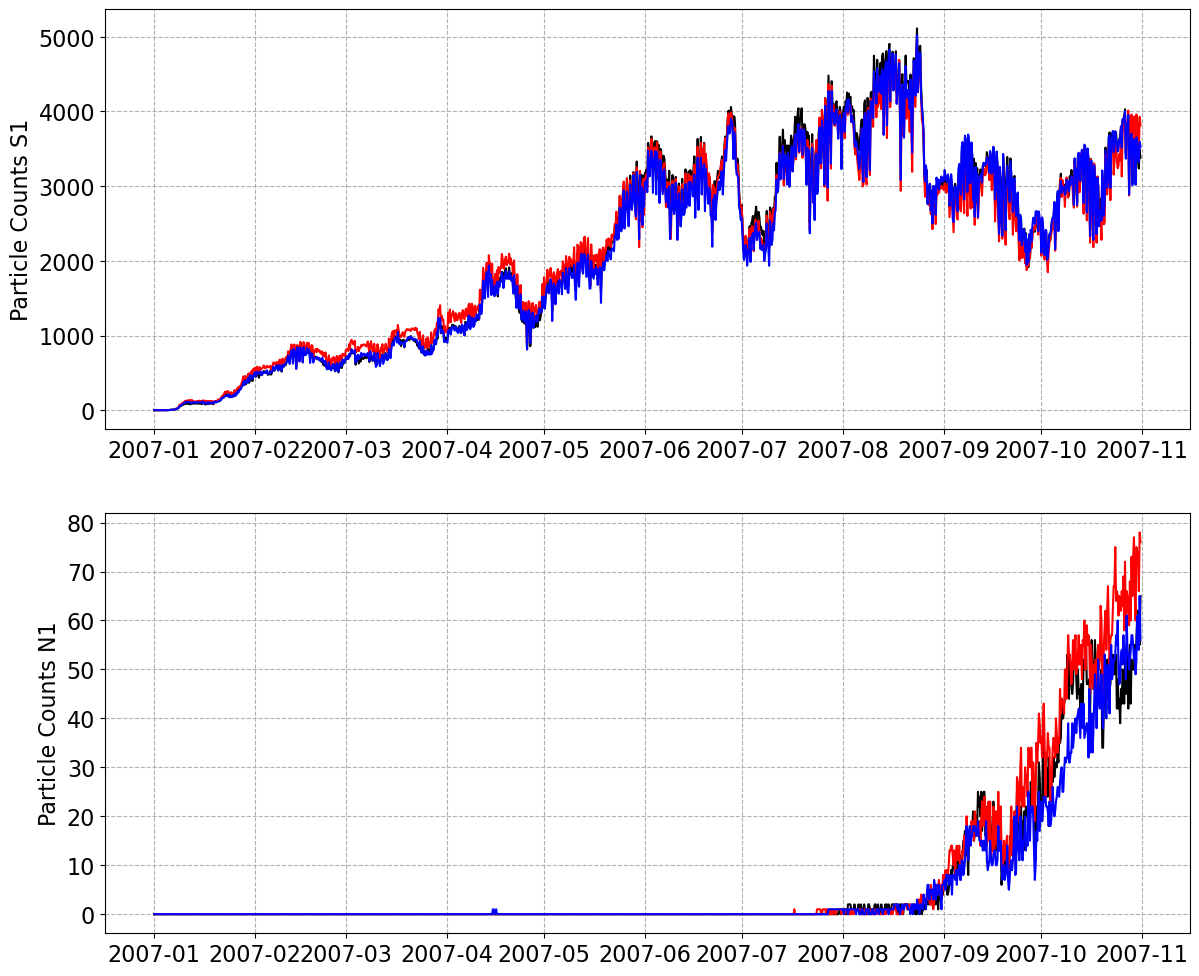

In [25]:
fig, ax = plt.subplots(2,1, figsize = (14,12))
ax[0].plot(counts_S1_V1_total, 'k')
ax[0].plot(counts_S1_V2_total, 'r')
ax[0].plot(counts_S1_V3_total, 'b')
ax[0].set_ylabel('Particle Counts S1')
#
ax[1].plot(counts_N1_V1_total, 'k')
ax[1].plot(counts_N1_V2_total, 'r')
ax[1].plot(counts_N1_V3_total, 'b')
ax[1].set_ylabel('Particle Counts N1')
#
for axis in ax:
    axis.grid(linestyle = '--')

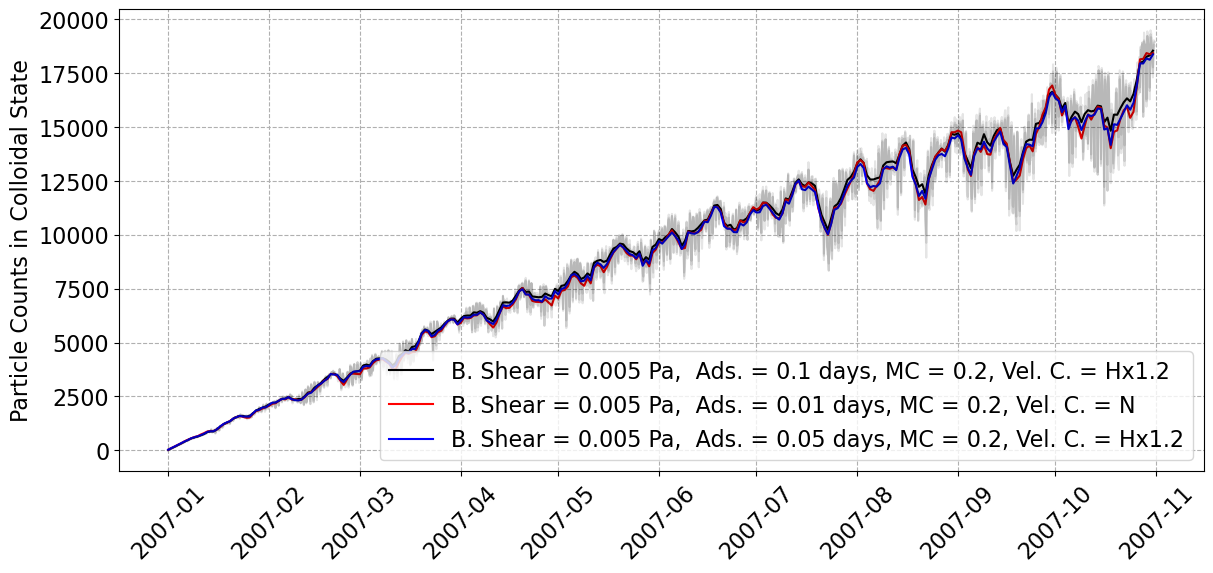

In [ ]:
#tt = data_V1.isel(obs=slice(0,1215))['time'][0,:].values
#fig, ax = plt.subplots(figsize = (14,6))
#ax.plot(tt[::4], prop_V1.colloidal_water.groupby(prop_V1.colloidal_water.index // 4).mean(), 'k', label = 'B. Shear = 0.005 Pa,  Ads. = 0.1 days, MC = 0.2, Vel. C. = Hx1.2')
#ax.plot(tt[::4], prop_V2.colloidal_water.groupby(prop_V2.colloidal_water.index // 4).mean(), 'r', label = 'B. Shear = 0.005 Pa,  Ads. = 0.01 days, MC = 0.2, Vel. C. = N')
#ax.plot(tt[::4], prop_V3.colloidal_water.groupby(prop_V3.colloidal_water.index // 4).mean(), 'b', label = 'B. Shear = 0.005 Pa,  Ads. = 0.05 days, MC = 0.2, Vel. C. = Hx1.2')
#
#ax.plot(tt, prop_V1.colloidal_water, 'k', alpha = .1)
#ax.plot(tt, prop_V2.colloidal_water, 'k', alpha = .1)
#ax.plot(tt, prop_V3.colloidal_water, 'k', alpha = .1)
#ax.tick_params(axis='x', rotation=45)
#
#ax.set_ylabel('Particle Counts in Colloidal State')
#ax.legend(loc = 'lower right')
#ax.grid(linestyle = '--')

In [ ]:
tt

array(['2007-01-01T00:30:00.000000000', '2007-01-01T06:30:00.000000000',
       '2007-01-01T12:30:00.000000000', ...,
       '2007-10-31T00:30:00.000000000', '2007-10-31T06:30:00.000000000',
       '2007-10-31T12:30:00.000000000'],
      shape=(1215,), dtype='datetime64[ns]')